# Phase 5 - Notebook 03: VGGT Architecture Deep Dive

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChunLI-666/3DGS-from-scratch/blob/develop/notebooks/phase5/03_architecture_deep_dive.ipynb)

---

## Learning Objectives

By the end of this notebook, you will:
1. Understand the complete VGGT network architecture from input to output
2. Learn the details of the DINOv2 backbone and its role in feature extraction
3. Master the Token Aggregator with 24 alternating attention layers
4. Understand special token design (Camera Token, Register Tokens)
5. Learn about patch embedding and positional encoding
6. Visualize the full data flow through the network

**Estimated Time**: 65 minutes

**Prerequisites**: Phase 5 Notebooks 01-02 (Alternating Attention, Multi-task Heads)

---

## 0. Environment Setup

In [1]:
# 环境设置 - Environment Setup
import os
import sys

# Colab兼容性
if 'COLAB_GPU' in os.environ:
    !pip install -q torch torchvision matplotlib numpy
    !git clone https://github.com/ChunLI-666/3DGS-from-scratch.git
    %cd 3DGS-from-scratch

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

print("环境就绪!")
print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

环境就绪!
NumPy version: 2.4.2
PyTorch version: 2.10.0+cu128
CUDA available: False


## 1. Complete Architecture Overview

### The Big Picture

VGGT consists of three main components:

```
Input Images (N × 518×518) → DINOv2 Encoder → Token Aggregator → Multi-task Heads
     ↓                           ↓                  ↓              ↓
  Camera params             Image tokens      Aggregated      Camera/Depth/
  (optional)               [N, 1374, C]       features        Point/Track
```

### Architecture Components

1. **DINOv2 Backbone**: Pre-trained Vision Transformer encoder
   - Processes each image independently
   - Outputs patch embeddings + special tokens
   - Extracts multi-scale features from layers [4, 11, 17, 23]

2. **Token Aggregator**: 24-layer alternating attention transformer
   - Processes all images together
   - Alternates between frame and global attention
   - Aggregates multi-view information

3. **Multi-task Heads**: Specialized output layers
   - Camera Head: Predicts camera poses and intrinsics
   - Depth Head: Dense depth prediction (DPT-based)
   - Point Head: Direct 3D point prediction (DPT-based)
   - Track Head: 2D point tracking (CoTracker-based)

Let's visualize this architecture:

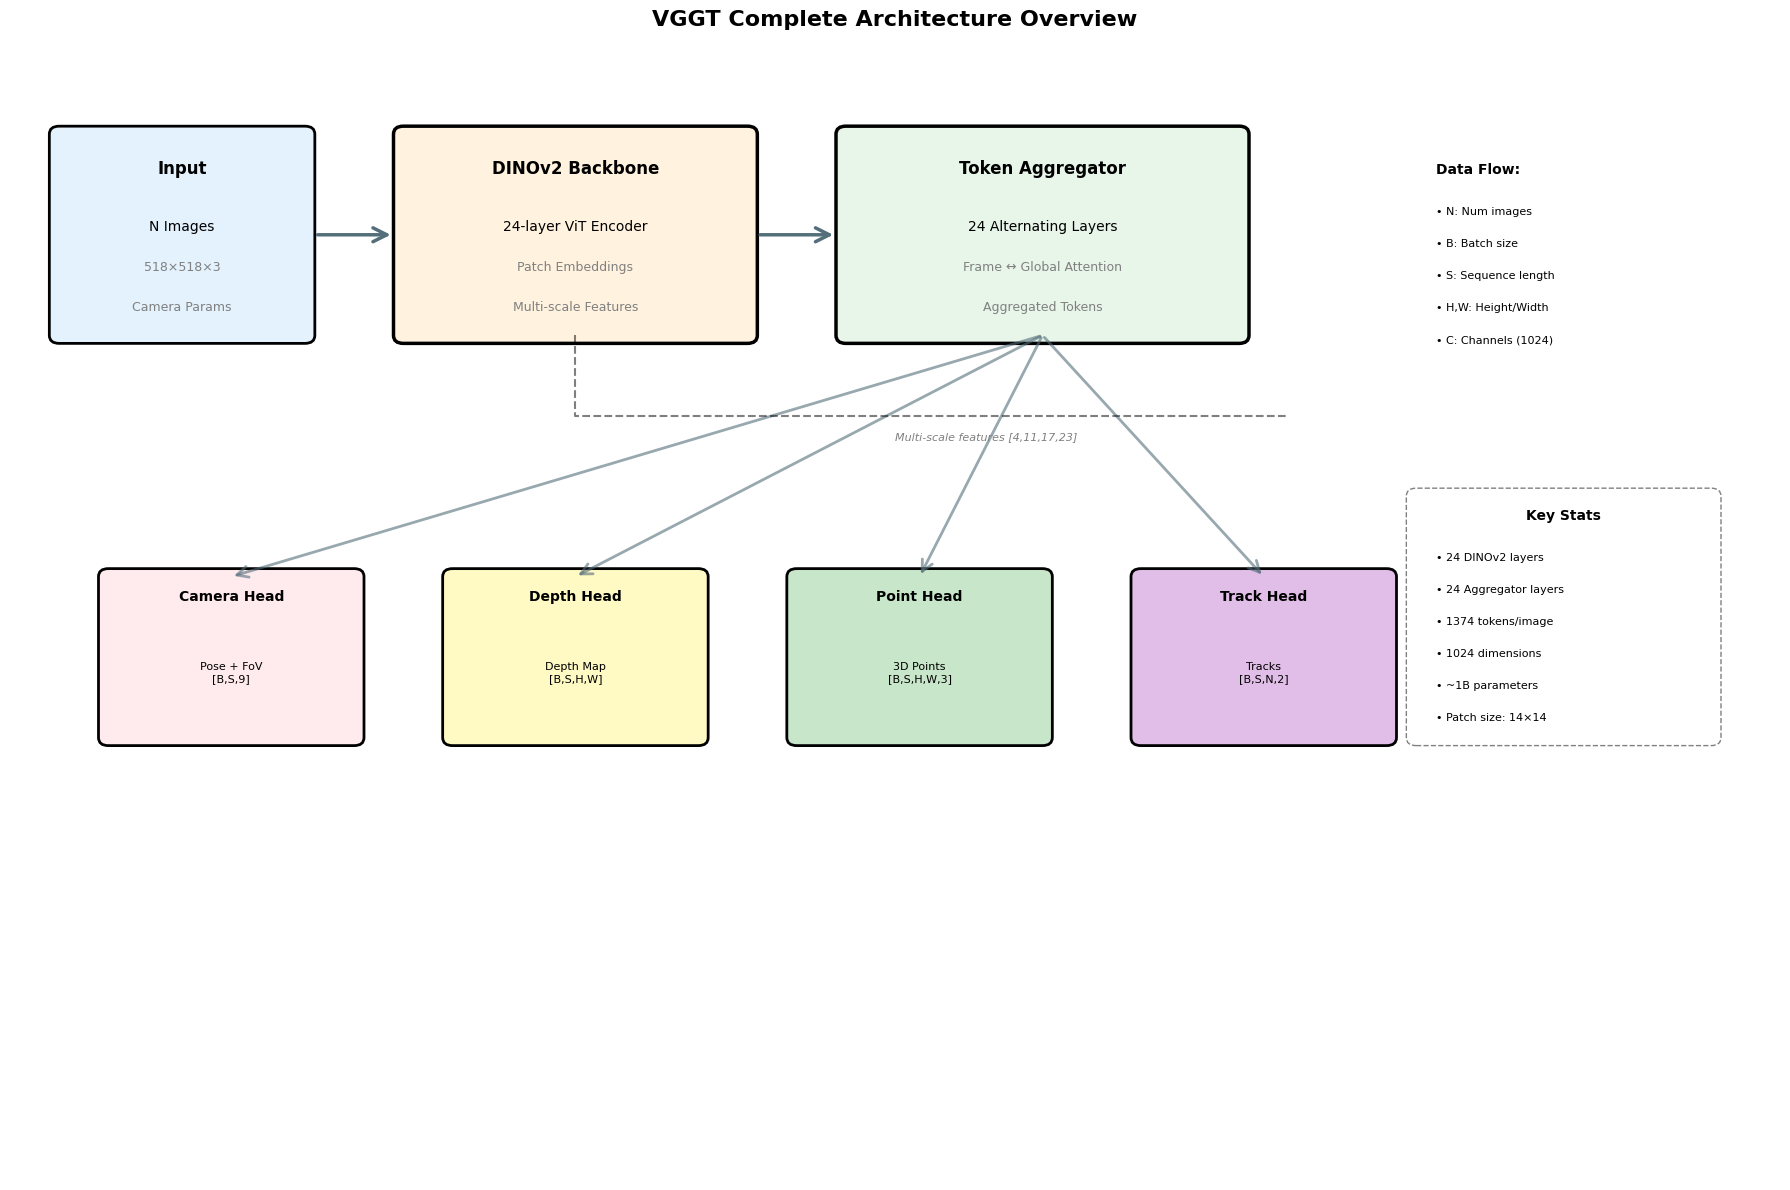


VGGT架构总结:
1. DINOv2: 独立处理每张图片,提取特征
2. Token Aggregator: 联合处理所有图片,聚合多视角信息
3. Multi-task Heads: 并行输出多个3D视觉任务的结果


In [2]:
# 完整架构图 - Complete Architecture Diagram
fig, ax = plt.subplots(1, 1, figsize=(18, 12))
ax.set_xlim(0, 18)
ax.set_ylim(0, 14)
ax.axis('off')
ax.set_title('VGGT Complete Architecture Overview', fontsize=16, fontweight='bold', pad=20)

# 颜色定义
colors = {
    'input': '#E3F2FD',
    'backbone': '#FFF3E0',
    'aggregator': '#E8F5E9',
    'camera_head': '#FFEBEE',
    'depth_head': '#FFF9C4',
    'point_head': '#C8E6C9',
    'track_head': '#E1BEE7',
    'arrow': '#546E7A'
}

# 1. Input Section
input_box = FancyBboxPatch((0.5, 10.5), 2.5, 2.5,
                          boxstyle="round,pad=0.1",
                          edgecolor='black', facecolor=colors['input'], linewidth=2)
ax.add_patch(input_box)
ax.text(1.75, 12.5, 'Input', fontsize=12, fontweight='bold', ha='center')
ax.text(1.75, 11.8, 'N Images', fontsize=10, ha='center')
ax.text(1.75, 11.3, '518×518×3', fontsize=9, ha='center', color='gray')
ax.text(1.75, 10.8, 'Camera Params', fontsize=9, ha='center', color='gray')

# 2. DINOv2 Backbone
backbone_box = FancyBboxPatch((4, 10.5), 3.5, 2.5,
                             boxstyle="round,pad=0.1",
                             edgecolor='black', facecolor=colors['backbone'], linewidth=2.5)
ax.add_patch(backbone_box)
ax.text(5.75, 12.5, 'DINOv2 Backbone', fontsize=12, fontweight='bold', ha='center')
ax.text(5.75, 11.8, '24-layer ViT Encoder', fontsize=10, ha='center')
ax.text(5.75, 11.3, 'Patch Embeddings', fontsize=9, ha='center', color='gray')
ax.text(5.75, 10.8, 'Multi-scale Features', fontsize=9, ha='center', color='gray')

# Arrow: Input → Backbone
arrow1 = FancyArrowPatch((3.1, 11.75), (3.9, 11.75),
                        arrowstyle='->', mutation_scale=25, linewidth=2.5,
                        color=colors['arrow'])
ax.add_patch(arrow1)

# 3. Token Aggregator
aggregator_box = FancyBboxPatch((8.5, 10.5), 4, 2.5,
                               boxstyle="round,pad=0.1",
                               edgecolor='black', facecolor=colors['aggregator'], linewidth=2.5)
ax.add_patch(aggregator_box)
ax.text(10.5, 12.5, 'Token Aggregator', fontsize=12, fontweight='bold', ha='center')
ax.text(10.5, 11.8, '24 Alternating Layers', fontsize=10, ha='center')
ax.text(10.5, 11.3, 'Frame ↔ Global Attention', fontsize=9, ha='center', color='gray')
ax.text(10.5, 10.8, 'Aggregated Tokens', fontsize=9, ha='center', color='gray')

# Arrow: Backbone → Aggregator
arrow2 = FancyArrowPatch((7.6, 11.75), (8.4, 11.75),
                        arrowstyle='->', mutation_scale=25, linewidth=2.5,
                        color=colors['arrow'])
ax.add_patch(arrow2)

# Multi-scale features branch (to heads)
ax.plot([5.75, 5.75, 13], [10.5, 9.5, 9.5], 'k--', linewidth=1.5, alpha=0.5)
ax.text(9, 9.2, 'Multi-scale features [4,11,17,23]', fontsize=8, style='italic', color='gray')

# 4. Multi-task Heads
heads_y = 5.5
head_width = 2.5
head_height = 2

heads = [
    {'name': 'Camera Head', 'x': 1, 'color': colors['camera_head'],
     'desc': 'Pose + FoV\n[B,S,9]'},
    {'name': 'Depth Head', 'x': 4.5, 'color': colors['depth_head'],
     'desc': 'Depth Map\n[B,S,H,W]'},
    {'name': 'Point Head', 'x': 8, 'color': colors['point_head'],
     'desc': '3D Points\n[B,S,H,W,3]'},
    {'name': 'Track Head', 'x': 11.5, 'color': colors['track_head'],
     'desc': 'Tracks\n[B,S,N,2]'}
]

for head in heads:
    # Head box
    box = FancyBboxPatch((head['x'], heads_y), head_width, head_height,
                        boxstyle="round,pad=0.1",
                        edgecolor='black', facecolor=head['color'], linewidth=2)
    ax.add_patch(box)
    ax.text(head['x'] + head_width/2, heads_y + head_height - 0.3,
           head['name'], fontsize=10, fontweight='bold', ha='center')
    ax.text(head['x'] + head_width/2, heads_y + head_height/2 - 0.2,
           head['desc'], fontsize=8, ha='center', va='center')
    
    # Arrow from aggregator
    arrow = FancyArrowPatch((10.5, 10.5), (head['x'] + head_width/2, heads_y + head_height),
                           arrowstyle='->', mutation_scale=20, linewidth=2,
                           color=colors['arrow'], alpha=0.6)
    ax.add_patch(arrow)

# Legend
legend_x = 14.5
legend_y = 12
ax.text(legend_x, legend_y + 0.5, 'Data Flow:', fontsize=10, fontweight='bold')
ax.text(legend_x, legend_y, '• N: Num images', fontsize=8)
ax.text(legend_x, legend_y - 0.4, '• B: Batch size', fontsize=8)
ax.text(legend_x, legend_y - 0.8, '• S: Sequence length', fontsize=8)
ax.text(legend_x, legend_y - 1.2, '• H,W: Height/Width', fontsize=8)
ax.text(legend_x, legend_y - 1.6, '• C: Channels (1024)', fontsize=8)

# Key stats box
stats_box = FancyBboxPatch((legend_x - 0.2, 5.5), 3, 3,
                          boxstyle="round,pad=0.1",
                          edgecolor='gray', facecolor='white', linewidth=1, linestyle='--')
ax.add_patch(stats_box)
ax.text(legend_x + 1.3, 8.2, 'Key Stats', fontsize=10, fontweight='bold', ha='center')
ax.text(legend_x, 7.7, '• 24 DINOv2 layers', fontsize=8)
ax.text(legend_x, 7.3, '• 24 Aggregator layers', fontsize=8)
ax.text(legend_x, 6.9, '• 1374 tokens/image', fontsize=8)
ax.text(legend_x, 6.5, '• 1024 dimensions', fontsize=8)
ax.text(legend_x, 6.1, '• ~1B parameters', fontsize=8)
ax.text(legend_x, 5.7, '• Patch size: 14×14', fontsize=8)

plt.tight_layout()
plt.savefig('vggt_architecture_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVGGT架构总结:")
print("1. DINOv2: 独立处理每张图片,提取特征")
print("2. Token Aggregator: 联合处理所有图片,聚合多视角信息")
print("3. Multi-task Heads: 并行输出多个3D视觉任务的结果")

## 2. DINOv2 Backbone Details

### What is DINOv2?

DINOv2 (Self-DIstillation with NO labels, version 2) is a self-supervised Vision Transformer trained by Meta AI.

**Key characteristics**:
- **Architecture**: Vision Transformer (ViT) with 24 layers
- **Training**: Self-supervised on 142M curated images
- **Patch size**: 14×14 pixels
- **Hidden dimension**: 1024 (for ViT-L variant used in VGGT)
- **Pre-trained weights**: Used as initialization in VGGT

### Why DINOv2 for VGGT?

1. **Strong visual representations**: Self-supervised learning captures rich visual features
2. **Transfer learning**: Pre-trained weights provide excellent initialization
3. **Multi-scale features**: Different layers capture different levels of abstraction
4. **Efficiency**: Well-optimized implementation available

### DINOv2 in VGGT

In VGGT, DINOv2 serves as the **encoder**:

```python
# DINOv2 processes each image independently
image_tokens = dinov2_encoder(images)  # [B, N, 1374, 1024]

# Multi-scale features extracted for dense prediction heads
features_layer_4 = dinov2.get_intermediate_layer(images, layer_id=4)
features_layer_11 = dinov2.get_intermediate_layer(images, layer_id=11)
features_layer_17 = dinov2.get_intermediate_layer(images, layer_id=17)
features_layer_23 = dinov2.get_intermediate_layer(images, layer_id=23)
```

### Layer-wise Feature Characteristics

| Layer | Level | Captures | Use Case |
|-------|-------|----------|----------|
| 4 | Early | Edges, textures, low-level features | Fine details |
| 11 | Low-mid | Corners, simple shapes | Local structure |
| 17 | High-mid | Object parts, semantic features | Object understanding |
| 23 | Late | Object semantics, global context | Scene understanding |

Let's visualize the layer-wise features:

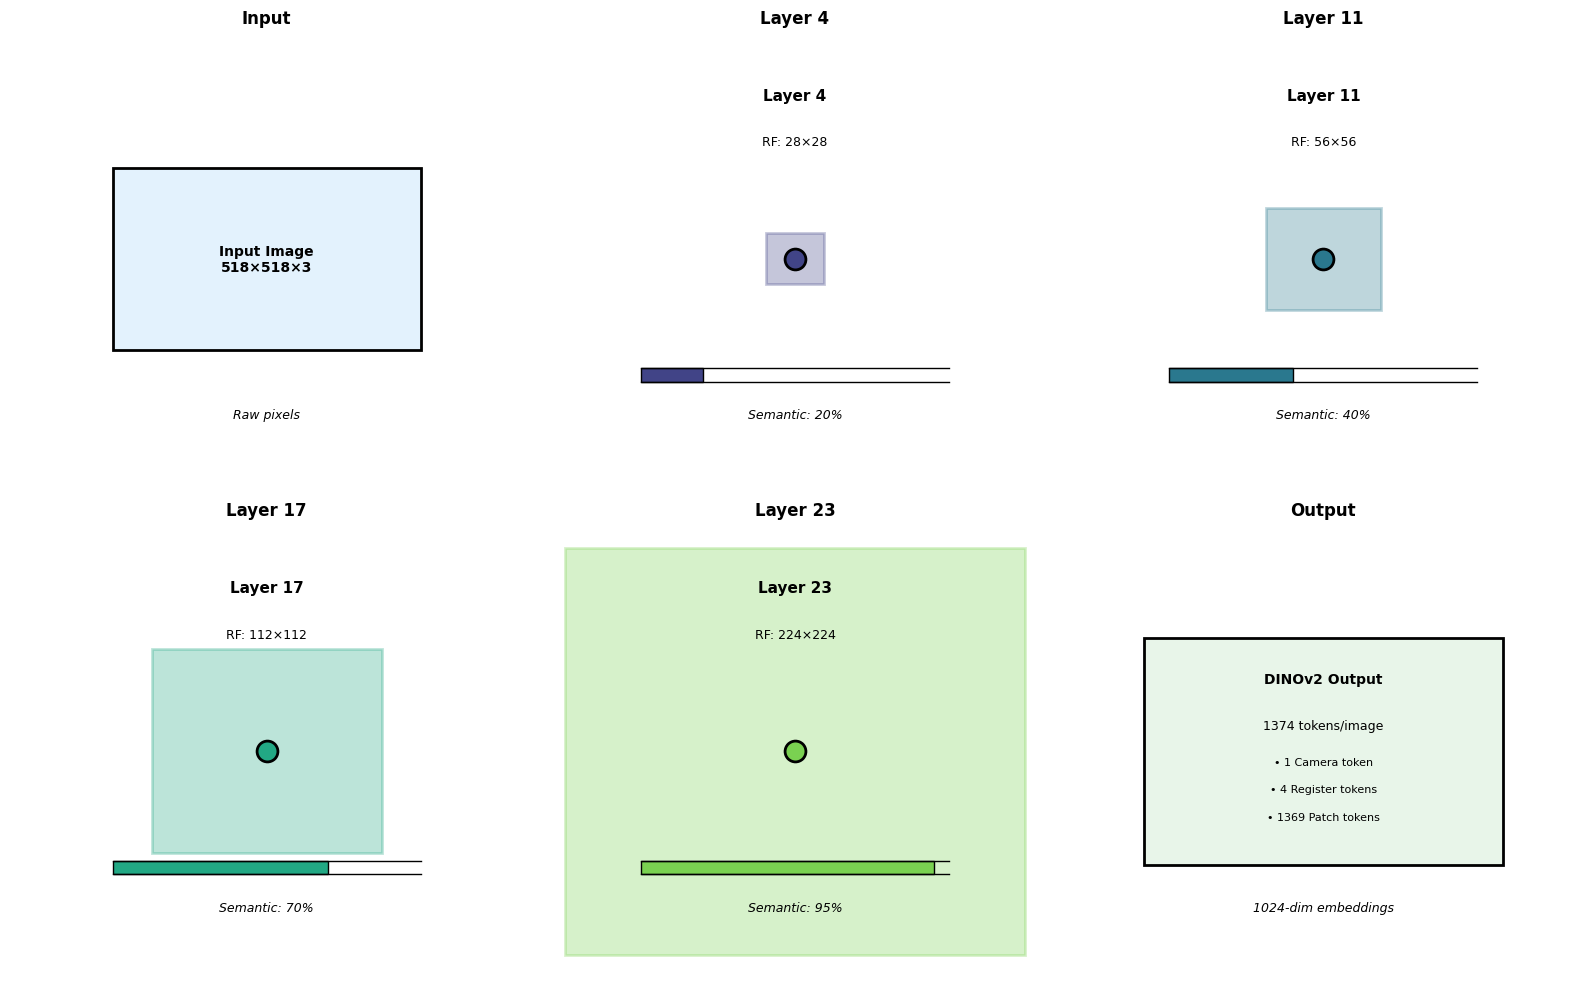


DINOv2 Layer Analysis:
• Early layers (1-4): Capture edges and textures
• Middle layers (5-12): Capture shapes and parts
• Deep layers (13-23): Capture semantics and context
• Final output: Rich 1024-dim token embeddings


In [3]:
# DINOv2 Layer Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 模拟不同层的特征统计
layers = [0, 4, 11, 17, 23, 24]
layer_names = ['Input', 'Layer 4', 'Layer 11', 'Layer 17', 'Layer 23', 'Output']

# 模拟特征统计 (receptive field size, semantic level)
receptive_fields = [14, 28, 56, 112, 224, 224]  # 感受野大小
semantic_levels = [0.0, 0.2, 0.4, 0.7, 0.95, 1.0]  # 语义级别
spatial_resolutions = [518, 518, 518, 518, 518, 518]  # 空间分辨率

colors_map = plt.cm.viridis(np.linspace(0, 1, len(layers)))

for idx, (layer, name) in enumerate(zip(layers, layer_names)):
    ax = axes[idx // 3, idx % 3]
    
    # 绘制特征金字塔概念图
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    if layer == 0:
        # Input image
        img_rect = Rectangle((2, 3), 6, 4, facecolor='#E3F2FD', edgecolor='black', linewidth=2)
        ax.add_patch(img_rect)
        ax.text(5, 5, 'Input Image\n518×518×3', ha='center', va='center', fontsize=10, fontweight='bold')
        ax.text(5, 1.5, 'Raw pixels', ha='center', fontsize=9, style='italic')
    elif layer == 24:
        # Final output
        img_rect = Rectangle((1.5, 2.5), 7, 5, facecolor='#E8F5E9', edgecolor='black', linewidth=2)
        ax.add_patch(img_rect)
        ax.text(5, 6.5, 'DINOv2 Output', ha='center', fontsize=10, fontweight='bold')
        ax.text(5, 5.5, '1374 tokens/image', ha='center', fontsize=9)
        ax.text(5, 4.7, '• 1 Camera token', ha='center', fontsize=8)
        ax.text(5, 4.1, '• 4 Register tokens', ha='center', fontsize=8)
        ax.text(5, 3.5, '• 1369 Patch tokens', ha='center', fontsize=8)
        ax.text(5, 1.5, '1024-dim embeddings', ha='center', fontsize=9, style='italic')
    else:
        # Intermediate layer
        rf_size = receptive_fields[idx]
        sem_level = semantic_levels[idx]
        
        # 绘制感受野示意图
        rf_rect = Rectangle((5 - rf_size/50, 5 - rf_size/50), 
                           rf_size/25, rf_size/25,
                           facecolor=colors_map[idx], alpha=0.3,
                           edgecolor=colors_map[idx], linewidth=2)
        ax.add_patch(rf_rect)
        
        # 中心点
        ax.plot([5], [5], 'o', markersize=15, color=colors_map[idx],
               markeredgecolor='black', markeredgewidth=2)
        
        # 信息
        ax.text(5, 8.5, f'Layer {layer}', ha='center', fontsize=11, fontweight='bold')
        ax.text(5, 7.5, f'RF: {rf_size}×{rf_size}', ha='center', fontsize=9)
        ax.text(5, 1.5, f'Semantic: {int(sem_level*100)}%', ha='center', fontsize=9, style='italic')
        
        # 进度条
        bar_rect = Rectangle((2, 2.3), 6 * sem_level, 0.3,
                            facecolor=colors_map[idx], edgecolor='black', linewidth=1)
        ax.add_patch(bar_rect)
        ax.plot([2, 8], [2.3, 2.3], 'k-', linewidth=1)
        ax.plot([2, 8], [2.6, 2.6], 'k-', linewidth=1)
    
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('dinov2_layers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDINOv2 Layer Analysis:")
print("• Early layers (1-4): Capture edges and textures")
print("• Middle layers (5-12): Capture shapes and parts")
print("• Deep layers (13-23): Capture semantics and context")
print("• Final output: Rich 1024-dim token embeddings")

### DINOv2 Architecture Details

The DINOv2 encoder consists of:

1. **Patch Embedding**:
   - Input: 518×518 image
   - Patch size: 14×14
   - Number of patches: 37×37 = 1369
   - Embedding: Linear projection to 1024 dimensions

2. **Positional Encoding**:
   - Learned positional embeddings added to patch embeddings
   - Shape: [1369, 1024]

3. **Transformer Layers** (24 total):
   - Each layer: Multi-head self-attention + FFN
   - Hidden dim: 1024
   - MLP ratio: 4× (4096 intermediate dim)
   - Heads: 16 attention heads

4. **Layer Normalization**: Pre-LN throughout

Let's look at the computational breakdown:

In [4]:
# DINOv2 Computational Analysis
print("=" * 70)
print("                    DINOv2 Computational Analysis")
print("=" * 70)

# 参数
img_size = 518
patch_size = 14
num_patches = (img_size // patch_size) ** 2
hidden_dim = 1024
num_layers = 24
num_heads = 16
mlp_ratio = 4

print(f"\nInput Configuration:")
print(f"  Image size: {img_size}×{img_size}")
print(f"  Patch size: {patch_size}×{patch_size}")
print(f"  Patches per image: {num_patches} ({int(num_patches**0.5)}×{int(num_patches**0.5)})")

print(f"\nModel Configuration:")
print(f"  Hidden dimension: {hidden_dim}")
print(f"  Number of layers: {num_layers}")
print(f"  Attention heads: {num_heads}")
print(f"  MLP ratio: {mlp_ratio}")

# 计算参数量
# Patch embedding
patch_embed_params = (patch_size ** 2) * 3 * hidden_dim + hidden_dim  # weight + bias

# Positional embedding
pos_embed_params = num_patches * hidden_dim

# Per-layer parameters
# Attention: QKV projection + output projection
attn_params = 4 * hidden_dim * hidden_dim + 4 * hidden_dim  # weights + biases

# FFN: 2 linear layers
ffn_params = hidden_dim * (mlp_ratio * hidden_dim) + (mlp_ratio * hidden_dim) + \
             (mlp_ratio * hidden_dim) * hidden_dim + hidden_dim

# Layer norm (2 per layer)
ln_params = 2 * (2 * hidden_dim)

layer_params = attn_params + ffn_params + ln_params

# Total
total_params = patch_embed_params + pos_embed_params + num_layers * layer_params

print(f"\nParameter Count:")
print(f"  Patch embedding: {patch_embed_params/1e6:.2f}M")
print(f"  Positional embedding: {pos_embed_params/1e6:.2f}M")
print(f"  Per layer: {layer_params/1e6:.2f}M")
print(f"  All {num_layers} layers: {num_layers * layer_params/1e6:.2f}M")
print(f"  TOTAL: {total_params/1e6:.2f}M parameters")

# 计算FLOPs
# Per layer
tokens = num_patches
attn_flops = 2 * tokens * tokens * hidden_dim  # QK^T and attn@V
ffn_flops = 2 * tokens * hidden_dim * mlp_ratio * hidden_dim
layer_flops = attn_flops + ffn_flops

print(f"\nFLOPs per image:")
print(f"  Attention per layer: {attn_flops/1e9:.2f} GFLOPs")
print(f"  FFN per layer: {ffn_flops/1e9:.2f} GFLOPs")
print(f"  Total per layer: {layer_flops/1e9:.2f} GFLOPs")
print(f"  All {num_layers} layers: {num_layers * layer_flops/1e9:.2f} GFLOPs")

print("\nKey Insights:")
print(f"  • Attention dominates computation: {attn_flops/(attn_flops+ffn_flops)*100:.1f}% of layer FLOPs")
print(f"  • Quadratic complexity in sequence length: O({tokens}²)")
print(f"  • For N images: multiply by N for independent processing")

                    DINOv2 Computational Analysis

Input Configuration:
  Image size: 518×518
  Patch size: 14×14
  Patches per image: 1369 (37×37)

Model Configuration:
  Hidden dimension: 1024
  Number of layers: 24
  Attention heads: 16
  MLP ratio: 4

Parameter Count:
  Patch embedding: 0.60M
  Positional embedding: 1.40M
  Per layer: 12.60M
  All 24 layers: 302.31M
  TOTAL: 304.31M parameters

FLOPs per image:
  Attention per layer: 3.84 GFLOPs
  FFN per layer: 11.48 GFLOPs
  Total per layer: 15.32 GFLOPs
  All 24 layers: 367.73 GFLOPs

Key Insights:
  • Attention dominates computation: 25.1% of layer FLOPs
  • Quadratic complexity in sequence length: O(1369²)
  • For N images: multiply by N for independent processing


## 3. Patch Embedding & Positional Encoding

### Patch Embedding

The first step in processing images is converting them into tokens:

```python
# 1. Divide image into patches
image: [3, 518, 518] → patches: [1369, 3, 14, 14]

# 2. Flatten and project
patches: [1369, 588] (3*14*14) → Linear(588, 1024) → [1369, 1024]
```

### Positional Encoding

Since transformers are permutation-invariant, we need positional information:

**Learned Positional Embeddings** (used in VGGT):
- Shape: [1369, 1024]
- Added to patch embeddings
- Each position (i, j) in the 37×37 grid has a unique learned embedding

**Why learned instead of sinusoidal?**
- Sufficient model capacity to learn optimal encodings
- Adapted to the visual domain during pre-training
- More flexible than fixed sinusoidal patterns

### Token Layout (Detailed)

After DINOv2 processing, each image produces:

```
Tokens: [CLS] [REG1] [REG2] [REG3] [REG4] [P0] [P1] ... [P1368]
        ↓    ↓     ↓     ↓     ↓     ↓    ↓        ↓
       Cam  Reg   Reg   Reg   Reg  Patch Patch   Patch
       1    4     4     4     4     1369 tokens
       token tokens                   (37×37 grid)

Total: 1 + 4 + 1369 = 1374 tokens per image
```

Note: VGGT modifies DINOv2's [CLS] token to serve as the Camera Token.

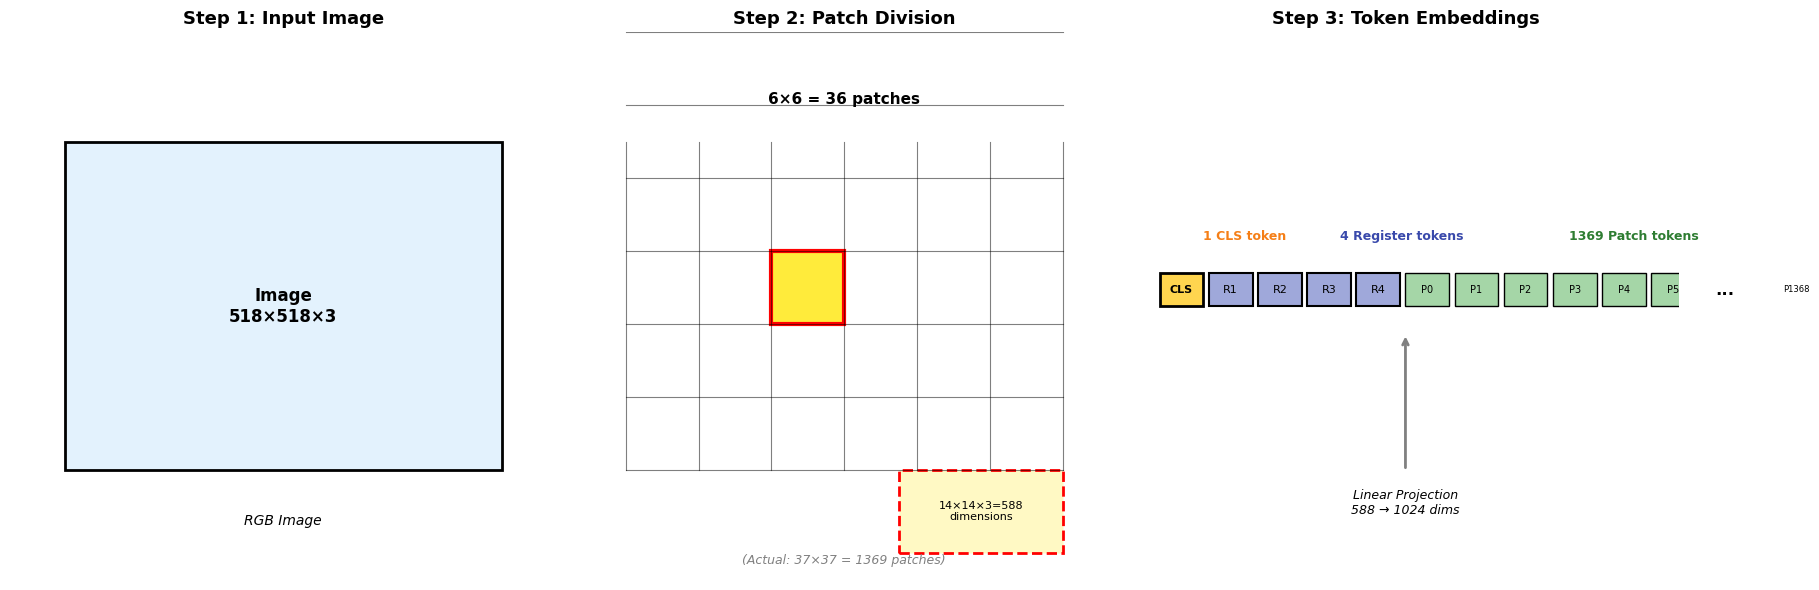


Patch Embedding Process:
1. Divide 518×518 image into 14×14 patches
2. Flatten each patch to 588-dim vector
3. Project to 1024-dim embedding space
4. Add learned positional embeddings
5. Result: 1374 tokens (1 CLS + 4 REG + 1369 PATCH)


In [5]:
# Patch Embedding Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original Image
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Step 1: Input Image', fontsize=13, fontweight='bold')

# Draw image
img_rect = Rectangle((1, 2), 8, 6, facecolor='#E3F2FD', edgecolor='black', linewidth=2)
ax.add_patch(img_rect)
ax.text(5, 5, 'Image\n518×518×3', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(5, 1, 'RGB Image', ha='center', fontsize=10, style='italic')

# 2. Patch Grid
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Step 2: Patch Division', fontsize=13, fontweight='bold')

# Draw grid (simplified to 6×6 for visualization)
n_patches = 6
patch_size = 8 / n_patches
grid_start = 1

for i in range(n_patches + 1):
    ax.plot([grid_start + i * patch_size, grid_start + i * patch_size],
           [2, 8], 'k-', linewidth=0.8, alpha=0.5)
    ax.plot([grid_start, grid_start + 8],
           [2 + i * patch_size, 2 + i * patch_size], 'k-', linewidth=0.8, alpha=0.5)

# Highlight one patch
highlight_patch = Rectangle((grid_start + 2 * patch_size, 2 + 2 * patch_size),
                           patch_size, patch_size,
                           facecolor='#FFEB3B', edgecolor='red', linewidth=3)
ax.add_patch(highlight_patch)

# Show patch detail
detail_rect = Rectangle((6, 0.5), 3, 1.5, facecolor='#FFF9C4',
                       edgecolor='red', linewidth=2, linestyle='--')
ax.add_patch(detail_rect)
ax.text(7.5, 1.25, '14×14×3=588\ndimensions', ha='center', va='center', fontsize=8)

ax.text(5, 8.7, f'{n_patches}×{n_patches} = {n_patches**2} patches', ha='center', fontsize=11, fontweight='bold')
ax.text(5, 0.3, '(Actual: 37×37 = 1369 patches)', ha='center', fontsize=9, style='italic', color='gray')

# 3. Token Embeddings
ax = axes[2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Step 3: Token Embeddings', fontsize=13, fontweight='bold')

# Draw token sequence
token_height = 0.6
token_width = 0.8
start_x = 0.5
y_pos = 5

# CLS token
cls_rect = Rectangle((start_x, y_pos), token_width, token_height,
                    facecolor='#FFD54F', edgecolor='black', linewidth=2)
ax.add_patch(cls_rect)
ax.text(start_x + token_width/2, y_pos + token_height/2, 'CLS',
       ha='center', va='center', fontsize=8, fontweight='bold')

# Register tokens
for i in range(4):
    reg_rect = Rectangle((start_x + (i+1) * (token_width + 0.1), y_pos),
                        token_width, token_height,
                        facecolor='#9FA8DA', edgecolor='black', linewidth=1.5)
    ax.add_patch(reg_rect)
    ax.text(start_x + (i+1) * (token_width + 0.1) + token_width/2,
           y_pos + token_height/2, f'R{i+1}',
           ha='center', va='center', fontsize=8)

# Patch tokens (show some)
for i in range(6):
    patch_rect = Rectangle((start_x + (i+5) * (token_width + 0.1), y_pos),
                          token_width, token_height,
                          facecolor='#A5D6A7', edgecolor='black', linewidth=1)
    ax.add_patch(patch_rect)
    ax.text(start_x + (i+5) * (token_width + 0.1) + token_width/2,
           y_pos + token_height/2, f'P{i}',
           ha='center', va='center', fontsize=7)

# Ellipsis
ax.text(start_x + 11.5 * (token_width + 0.1), y_pos + token_height/2,
       '...', ha='center', va='center', fontsize=12, fontweight='bold')

# Last patch
last_rect = Rectangle((start_x + 12.5 * (token_width + 0.1), y_pos),
                     token_width, token_height,
                     facecolor='#A5D6A7', edgecolor='black', linewidth=1)
ax.add_patch(last_rect)
ax.text(start_x + 12.5 * (token_width + 0.1) + token_width/2,
       y_pos + token_height/2, 'P1368',
       ha='center', va='center', fontsize=6)

# Labels
ax.text(1.3, y_pos + 1.2, '1 CLS token', fontsize=9, color='#F57F17', fontweight='bold')
ax.text(3.8, y_pos + 1.2, '4 Register tokens', fontsize=9, color='#3949AB', fontweight='bold')
ax.text(8, y_pos + 1.2, '1369 Patch tokens', fontsize=9, color='#2E7D32', fontweight='bold')

# Arrow showing projection
ax.annotate('', xy=(5, y_pos - 0.5), xytext=(5, 2),
           arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.text(5, 1.2, 'Linear Projection\n588 → 1024 dims', ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('patch_embedding.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPatch Embedding Process:")
print("1. Divide 518×518 image into 14×14 patches")
print("2. Flatten each patch to 588-dim vector")
print("3. Project to 1024-dim embedding space")
print("4. Add learned positional embeddings")
print("5. Result: 1374 tokens (1 CLS + 4 REG + 1369 PATCH)")

## 4. Token Aggregator Deep Dive

The Token Aggregator is the heart of VGGT. It takes the DINOv2 output tokens and aggregates information across all input images.

### Architecture Overview

```
Input: [B, N, 1374, 1024] tokens from DINOv2
       ↓
Layer 1 (Frame):  Process within each image independently
Layer 2 (Global): Process all tokens together
Layer 3 (Frame):  Process within each image independently
Layer 4 (Global): Process all tokens together
...
Layer 24 (Global): Final aggregation
       ↓
Output: [B, N, 1374, 1024] aggregated tokens
```

### Key Components

1. **24 Transformer Layers**: Alternating attention pattern
2. **Pre-LN**: Layer normalization before attention/FFN
3. **Residual Connections**: Around each sub-layer
4. **MLP**: 4× expansion ratio (4096 hidden dim)

### Attention Patterns

**Frame Attention (Odd layers: 1, 3, 5, ..., 23)**: 
- Each image processed independently
- Attention mask: Block diagonal
- Complexity: O(N × T²) where T = 1374

**Global Attention (Even layers: 2, 4, 6, ..., 24)**: 
- All images processed together
- Attention mask: Full connectivity
- Complexity: O((N × T)²)

Let's visualize the Token Aggregator:

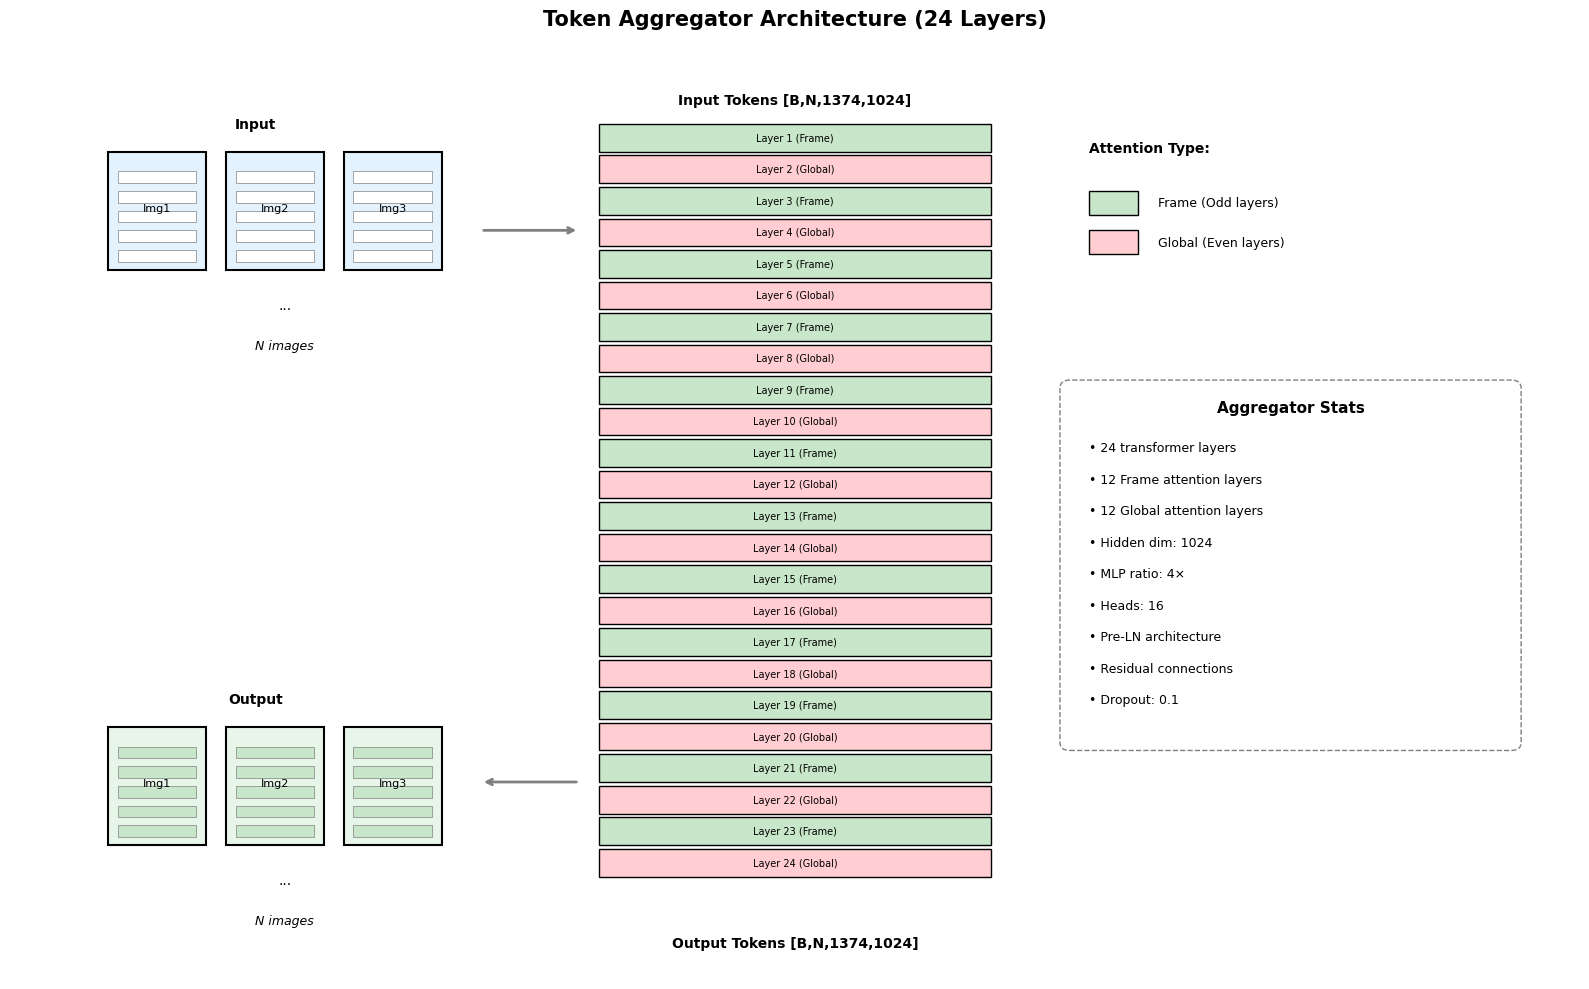


Token Aggregator Summary:
• 12 layers use Frame attention (within-image)
• 12 layers use Global attention (cross-image)
• Alternating pattern enables efficient multi-view processing
• Output tokens contain aggregated multi-view information


In [6]:
# Token Aggregator Visualization
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('Token Aggregator Architecture (24 Layers)', fontsize=15, fontweight='bold')

# Draw layer stack
layer_height = 0.35
layer_width = 4
start_y = 10.5
start_x = 6

# Draw all 24 layers
for i in range(24):
    layer_num = i + 1
    is_global = layer_num % 2 == 0
    
    # Color based on attention type
    color = '#FFCDD2' if is_global else '#C8E6C9'  # Red for global, Green for frame
    layer_type = 'Global' if is_global else 'Frame'
    
    y = start_y - i * (layer_height + 0.05)
    
    # Layer box
    layer_rect = Rectangle((start_x, y), layer_width, layer_height,
                          facecolor=color, edgecolor='black', linewidth=1)
    ax.add_patch(layer_rect)
    
    # Layer number and type
    ax.text(start_x + layer_width/2, y + layer_height/2,
           f'Layer {layer_num} ({layer_type})',
           ha='center', va='center', fontsize=7)

# Input label
ax.text(start_x + layer_width/2, start_y + 0.6,
       'Input Tokens [B,N,1374,1024]',
       ha='center', fontsize=10, fontweight='bold')

# Output label
ax.text(start_x + layer_width/2, start_y - 24 * (layer_height + 0.05) - 0.5,
       'Output Tokens [B,N,1374,1024]',
       ha='center', fontsize=10, fontweight='bold')

# Legend
legend_x = 11
legend_y = 10
ax.text(legend_x, legend_y + 0.5, 'Attention Type:', fontsize=10, fontweight='bold')

legend_rect1 = Rectangle((legend_x, legend_y - 0.3), 0.5, 0.3,
                        facecolor='#C8E6C9', edgecolor='black', linewidth=1)
ax.add_patch(legend_rect1)
ax.text(legend_x + 0.7, legend_y - 0.15, 'Frame (Odd layers)', fontsize=9, va='center')

legend_rect2 = Rectangle((legend_x, legend_y - 0.8), 0.5, 0.3,
                        facecolor='#FFCDD2', edgecolor='black', linewidth=1)
ax.add_patch(legend_rect2)
ax.text(legend_x + 0.7, legend_y - 0.65, 'Global (Even layers)', fontsize=9, va='center')

# Statistics box
stats_box = FancyBboxPatch((legend_x - 0.2, 3), 4.5, 4.5,
                          boxstyle="round,pad=0.1",
                          edgecolor='gray', facecolor='white', linewidth=1, linestyle='--')
ax.add_patch(stats_box)

ax.text(legend_x + 2.05, 7.2, 'Aggregator Stats', fontsize=11, fontweight='bold', ha='center')
ax.text(legend_x, 6.7, '• 24 transformer layers', fontsize=9)
ax.text(legend_x, 6.3, '• 12 Frame attention layers', fontsize=9)
ax.text(legend_x, 5.9, '• 12 Global attention layers', fontsize=9)
ax.text(legend_x, 5.5, '• Hidden dim: 1024', fontsize=9)
ax.text(legend_x, 5.1, '• MLP ratio: 4×', fontsize=9)
ax.text(legend_x, 4.7, '• Heads: 16', fontsize=9)
ax.text(legend_x, 4.3, '• Pre-LN architecture', fontsize=9)
ax.text(legend_x, 3.9, '• Residual connections', fontsize=9)
ax.text(legend_x, 3.5, '• Dropout: 0.1', fontsize=9)

# Input/Output visualization
io_x = 1

# Input
ax.text(io_x + 1.5, 10.8, 'Input', fontsize=10, fontweight='bold', ha='center')
for i in range(3):
    rect = Rectangle((io_x + i * 1.2, 9), 1, 1.5,
                    facecolor='#E3F2FD', edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(io_x + i * 1.2 + 0.5, 9.75, f'Img{i+1}', ha='center', fontsize=8)
    # Show tokens inside
    for j in range(5):
        small_rect = Rectangle((io_x + i * 1.2 + 0.1, 9.1 + j * 0.25), 0.8, 0.15,
                              facecolor='white', edgecolor='gray', linewidth=0.5)
        ax.add_patch(small_rect)
ax.text(io_x + 1.8, 8.5, '...', ha='center', fontsize=10)
ax.text(io_x + 1.8, 8, 'N images', ha='center', fontsize=9, style='italic')

# Arrow to aggregator
ax.annotate('', xy=(5.8, 9.5), xytext=(4.8, 9.5),
           arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# Output
ax.text(io_x + 1.5, 3.5, 'Output', fontsize=10, fontweight='bold', ha='center')
for i in range(3):
    rect = Rectangle((io_x + i * 1.2, 1.7), 1, 1.5,
                    facecolor='#E8F5E9', edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(io_x + i * 1.2 + 0.5, 2.45, f'Img{i+1}', ha='center', fontsize=8)
    # Show aggregated tokens
    for j in range(5):
        small_rect = Rectangle((io_x + i * 1.2 + 0.1, 1.8 + j * 0.25), 0.8, 0.15,
                              facecolor='#C8E6C9', edgecolor='gray', linewidth=0.5)
        ax.add_patch(small_rect)
ax.text(io_x + 1.8, 1.2, '...', ha='center', fontsize=10)
ax.text(io_x + 1.8, 0.7, 'N images', ha='center', fontsize=9, style='italic')

# Arrow from aggregator
ax.annotate('', xy=(4.8, 2.5), xytext=(5.8, 2.5),
           arrowprops=dict(arrowstyle='->', color='gray', lw=2))

plt.tight_layout()
plt.savefig('token_aggregator.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nToken Aggregator Summary:")
print("• 12 layers use Frame attention (within-image)")
print("• 12 layers use Global attention (cross-image)")
print("• Alternating pattern enables efficient multi-view processing")
print("• Output tokens contain aggregated multi-view information")

## 5. Special Token Design

Special tokens are crucial for VGGT's multi-view processing. Let's examine each type.

### 1. Camera Token (Formerly [CLS] token)

**Purpose**: Encode camera parameters and serve as a per-image representation

**Inheritance from DINOv2**: DINOv2 adds a [CLS] token at position 0. VGGT repurposes this as the Camera Token.

**Role**: 
- Aggregates image-level information during frame attention
- Participates in cross-view correspondence during global attention
- Input to Camera Head for pose prediction
- Encodes camera intrinsics and extrinsics implicitly

### 2. Register Tokens (4 tokens)

**Purpose**: Provide additional capacity for global information aggregation

**Design Inspiration**: Similar to [CLS] token in BERT, but multiple registers allow:
- Distributed memory for different types of information
- More flexible global context aggregation
- Better handling of complex scenes

**Role**: 
- During frame attention: Aggregate within-image context
- During global attention: Facilitate cross-image information flow
- Act as "bottleneck" for efficient communication

### 3. Patch Tokens

**Purpose**: Represent local image regions

**Properties**:
- Each corresponds to a 14×14 pixel region
- Positional encoding encodes spatial location
- During frame attention: Exchange local context
- During global attention: Find cross-view correspondences

### Token Indexing Convention

```python
# VGGT uses this convention throughout the code
patch_start_index = 5  # After 1 camera + 4 register tokens

# Accessing different token types
camera_tokens = tokens[:, :, 0, :]       # [B, N, 1024]
register_tokens = tokens[:, :, 1:5, :]   # [B, N, 4, 1024]
patch_tokens = tokens[:, :, 5:, :]       # [B, N, 1369, 1024]
```

Let's visualize the special tokens:

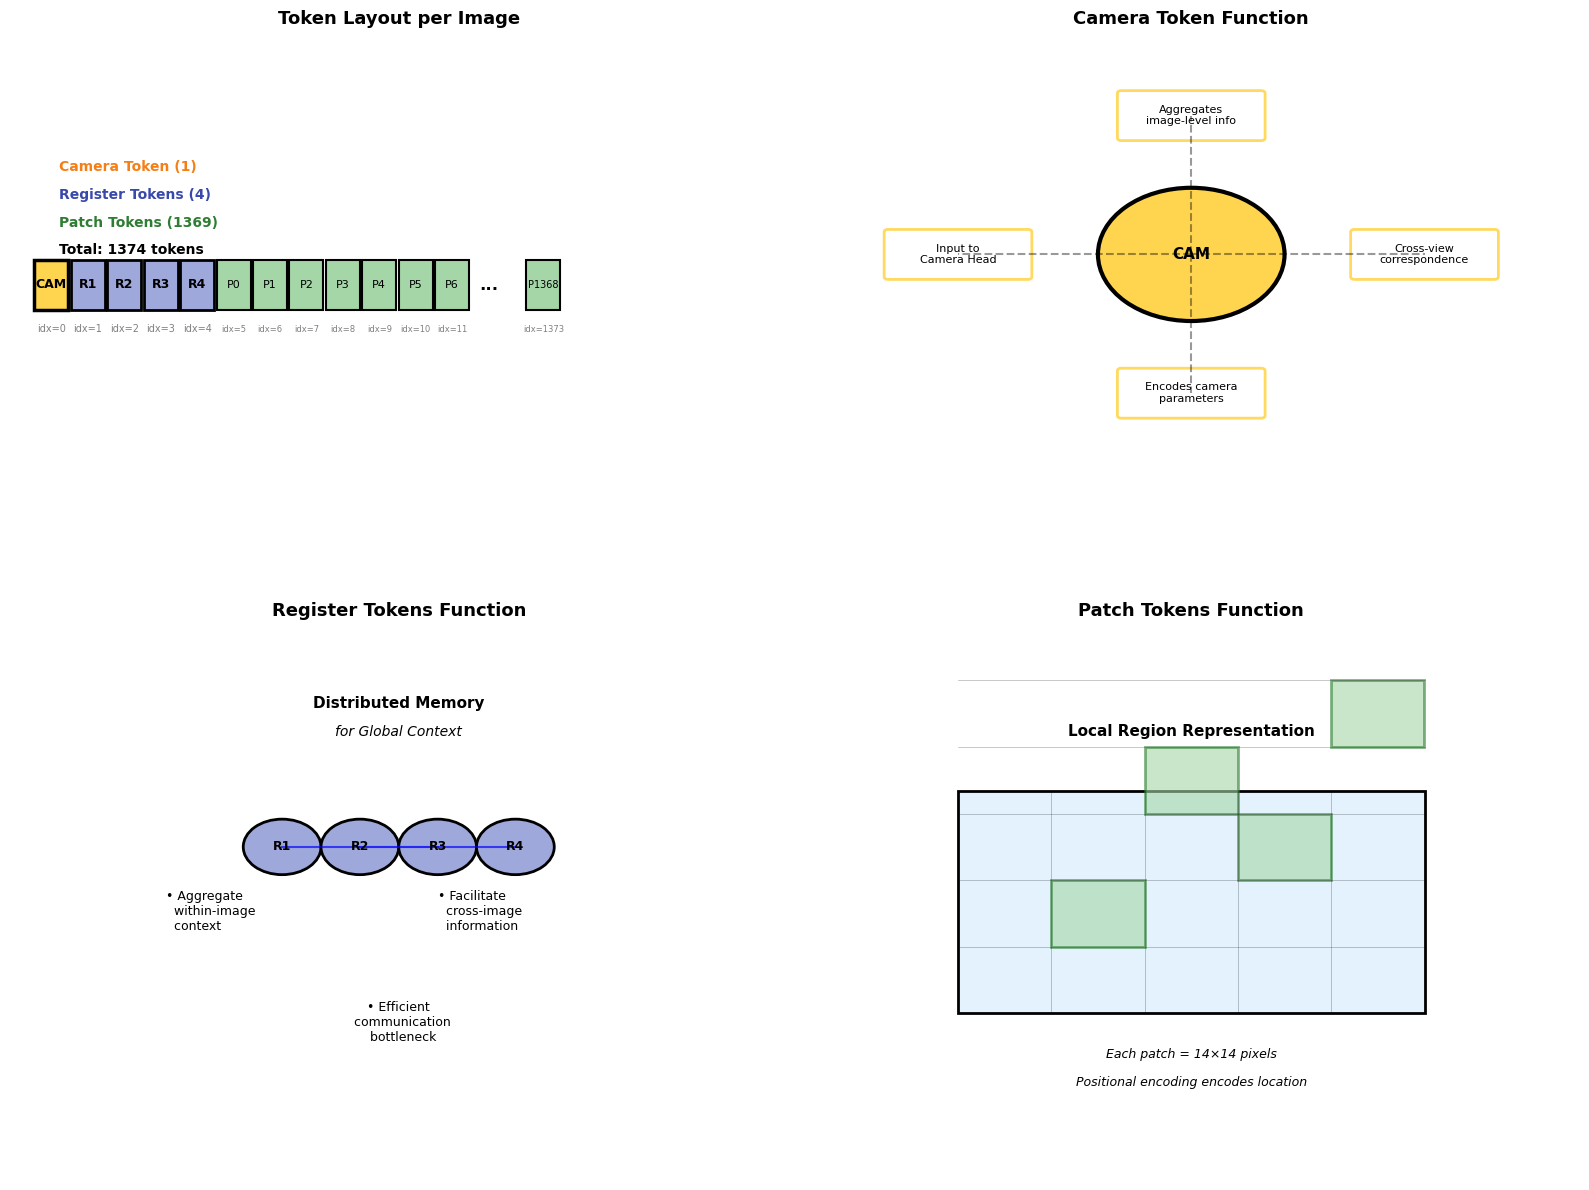


Special Tokens Summary:
• Camera Token: Image-level representation, pose prediction
• Register Tokens (4): Distributed memory for global context
• Patch Tokens (1369): Local region representations
• patch_start_index = 5 (important for indexing)


In [7]:
# Special Tokens Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Token Layout
ax = axes[0, 0]
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Token Layout per Image', fontsize=13, fontweight='bold')

# Draw token sequence
token_width = 0.7
token_height = 0.9
spacing = 0.05
start_x = 0.5
y_center = 5

# Camera token
cam_rect = Rectangle((start_x, y_center), token_width, token_height,
                    facecolor='#FFD54F', edgecolor='black', linewidth=2.5)
ax.add_patch(cam_rect)
ax.text(start_x + token_width/2, y_center + token_height/2, 'CAM',
       ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(start_x + token_width/2, y_center - 0.4, 'idx=0',
       ha='center', fontsize=7, color='gray')

# Register tokens
for i in range(4):
    x = start_x + (i + 1) * (token_width + spacing)
    reg_rect = Rectangle((x, y_center), token_width, token_height,
                        facecolor='#9FA8DA', edgecolor='black', linewidth=2)
    ax.add_patch(reg_rect)
    ax.text(x + token_width/2, y_center + token_height/2, f'R{i+1}',
           ha='center', va='center', fontsize=9, fontweight='bold')
    ax.text(x + token_width/2, y_center - 0.4, f'idx={i+1}',
           ha='center', fontsize=7, color='gray')

# Patch tokens (show subset)
for i in range(8):
    x = start_x + (i + 5) * (token_width + spacing)
    if i < 7:
        patch_rect = Rectangle((x, y_center), token_width, token_height,
                              facecolor='#A5D6A7', edgecolor='black', linewidth=1.5)
        ax.add_patch(patch_rect)
        ax.text(x + token_width/2, y_center + token_height/2, f'P{i}',
               ha='center', va='center', fontsize=8)
        ax.text(x + token_width/2, y_center - 0.4, f'idx={5+i}',
               ha='center', fontsize=6, color='gray')
    else:
        ax.text(x + token_width/2, y_center + token_height/2, '...',
               ha='center', va='center', fontsize=12, fontweight='bold')

# Last patch
x = start_x + 13.5 * (token_width + spacing)
patch_rect = Rectangle((x, y_center), token_width, token_height,
                      facecolor='#A5D6A7', edgecolor='black', linewidth=1.5)
ax.add_patch(patch_rect)
ax.text(x + token_width/2, y_center + token_height/2, 'P1368',
       ha='center', va='center', fontsize=7)
ax.text(x + token_width/2, y_center - 0.4, 'idx=1373',
       ha='center', fontsize=6, color='gray')

# Legend
ax.text(1, 7.5, 'Camera Token (1)', fontsize=10, color='#F57F17', fontweight='bold')
ax.text(1, 7, 'Register Tokens (4)', fontsize=10, color='#3949AB', fontweight='bold')
ax.text(1, 6.5, 'Patch Tokens (1369)', fontsize=10, color='#2E7D32', fontweight='bold')
ax.text(1, 6, 'Total: 1374 tokens', fontsize=10, fontweight='bold')

# 2. Camera Token Detail
ax = axes[0, 1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Camera Token Function', fontsize=13, fontweight='bold')

# Draw camera token
cam_center = (5, 6)
cam_circle = Circle(cam_center, 1.2, facecolor='#FFD54F', edgecolor='black', linewidth=3)
ax.add_patch(cam_circle)
ax.text(cam_center[0], cam_center[1], 'CAM', ha='center', va='center',
       fontsize=11, fontweight='bold')

# Functions
functions = [
    ('Aggregates\nimage-level info', (5, 8.5)),
    ('Input to\nCamera Head', (2, 6)),
    ('Cross-view\ncorrespondence', (8, 6)),
    ('Encodes camera\nparameters', (5, 3.5))
]

for text, pos in functions:
    # Draw connection line
    ax.plot([cam_center[0], pos[0]], [cam_center[1], pos[1]],
           'k--', linewidth=1.5, alpha=0.4)
    # Draw text box
    box = FancyBboxPatch((pos[0] - 0.9, pos[1] - 0.4), 1.8, 0.8,
                        boxstyle="round,pad=0.05",
                        facecolor='white', edgecolor='#FFD54F',
                        linewidth=2, alpha=0.9)
    ax.add_patch(box)
    ax.text(pos[0], pos[1], text, ha='center', va='center', fontsize=8)

# 3. Register Tokens Detail
ax = axes[1, 0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Register Tokens Function', fontsize=13, fontweight='bold')

# Draw 4 registers as a group
reg_centers = [(3.5, 6), (4.5, 6), (5.5, 6), (6.5, 6)]
for i, center in enumerate(reg_centers):
    reg_circle = Circle(center, 0.5, facecolor='#9FA8DA', edgecolor='black', linewidth=2)
    ax.add_patch(reg_circle)
    ax.text(center[0], center[1], f'R{i+1}', ha='center', va='center',
           fontsize=9, fontweight='bold')

# Draw connections between registers (global communication)
for i in range(len(reg_centers)):
    for j in range(i+1, len(reg_centers)):
        ax.plot([reg_centers[i][0], reg_centers[j][0]],
               [reg_centers[i][1], reg_centers[j][1]],
               'b-', linewidth=1.5, alpha=0.3)

# Functions
ax.text(5, 8.5, 'Distributed Memory', ha='center', fontsize=11, fontweight='bold')
ax.text(5, 8, 'for Global Context', ha='center', fontsize=10, style='italic')

ax.text(2, 4.5, '• Aggregate\n  within-image\n  context', fontsize=9)
ax.text(5.5, 4.5, '• Facilitate\n  cross-image\n  information', fontsize=9)
ax.text(5, 2.5, '• Efficient\n  communication\n  bottleneck', fontsize=9, ha='center')

# 4. Patch Tokens Detail
ax = axes[1, 1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Patch Tokens Function', fontsize=13, fontweight='bold')

# Draw image with patch grid
img_rect = Rectangle((2, 3), 6, 4, facecolor='#E3F2FD', edgecolor='black', linewidth=2)
ax.add_patch(img_rect)

# Draw grid
n_grid = 5
cell_size = 6 / n_grid
for i in range(n_grid + 1):
    ax.plot([2 + i * cell_size, 2 + i * cell_size], [3, 7], 'k-', alpha=0.3, linewidth=0.5)
    ax.plot([2, 8], [3 + i * cell_size, 3 + i * cell_size], 'k-', alpha=0.3, linewidth=0.5)

# Highlight some patches
highlight_patches = [(1, 1), (2, 3), (3, 2), (4, 4)]
for (i, j) in highlight_patches:
    rect = Rectangle((2 + i * cell_size, 3 + j * cell_size),
                    cell_size, cell_size,
                    facecolor='#A5D6A7', alpha=0.6, edgecolor='#2E7D32', linewidth=2)
    ax.add_patch(rect)

# Labels
ax.text(5, 8, 'Local Region Representation', ha='center', fontsize=11, fontweight='bold')
ax.text(5, 2.2, 'Each patch = 14×14 pixels', ha='center', fontsize=9, style='italic')
ax.text(5, 1.7, 'Positional encoding encodes location', ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('special_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSpecial Tokens Summary:")
print("• Camera Token: Image-level representation, pose prediction")
print("• Register Tokens (4): Distributed memory for global context")
print("• Patch Tokens (1369): Local region representations")
print("• patch_start_index = 5 (important for indexing)")

## 6. Alternating Attention Visualization

Let's visualize how attention patterns differ between frame and global modes.

### Attention Matrix Patterns

For 3 images with 10 tokens each (simplified):

**Global Attention**:
```
     Img1      Img2      Img3
    [XXXXX | XXXXX | XXXXX]  Img1
    [XXXXX | XXXXX | XXXXX]  Img1
    [XXXXX | XXXXX | XXXXX]  Img1
    -----------------------
    [XXXXX | XXXXX | XXXXX]  Img2
    [XXXXX | XXXXX | XXXXX]  Img2
    [XXXXX | XXXXX | XXXXX]  Img2
    -----------------------
    [XXXXX | XXXXX | XXXXX]  Img3
    [XXXXX | XXXXX | XXXXX]  Img3
    [XXXXX | XXXXX | XXXXX]  Img3
```

**Frame Attention**:
```
     Img1      Img2      Img3
    [XXX |   |   ]  Img1
    [XXX |   |   ]  Img1
    [XXX |   |   ]  Img1
    ----|-----------
    [   | XXX |   ]  Img2
    [   | XXX |   ]  Img2
    [   | XXX |   ]  Img2
    ----|-----------
    [   |   | XXX]  Img3
    [   |   | XXX]  Img3
    [   |   | XXX]  Img3
```

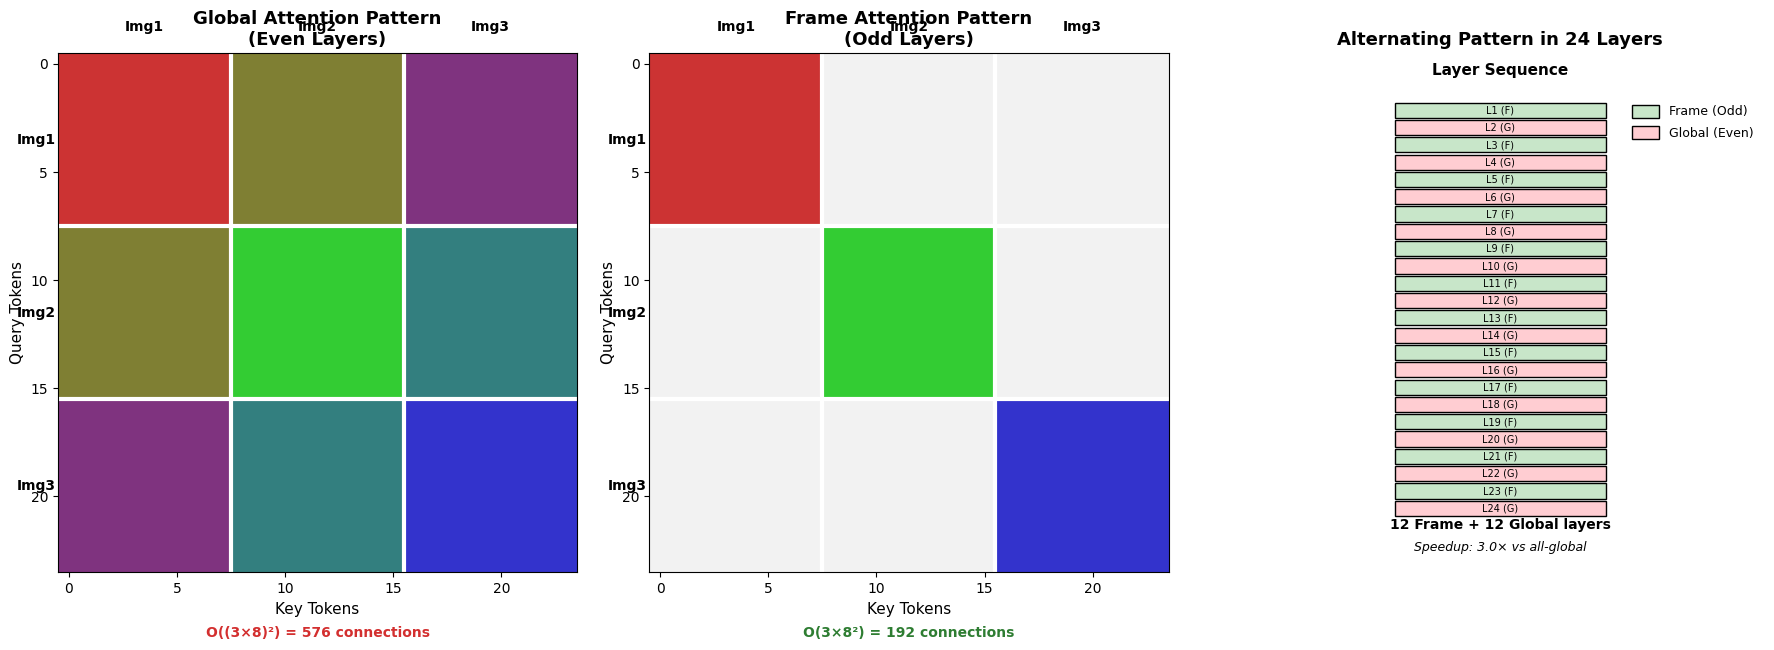


Attention Pattern Comparison:
• Global: 576 connections per layer
• Frame: 192 connections per layer
• Speedup: 3.0×


In [8]:
# Alternating Attention Pattern Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Parameters
N = 3  # 3 images
T = 8  # 8 tokens per image
total_tokens = N * T

# 1. Global Attention Pattern
ax = axes[0]
global_mask = np.ones((total_tokens, total_tokens))

# Create colored mask
colors_global = np.zeros((total_tokens, total_tokens, 3))
img_colors = [np.array([0.8, 0.2, 0.2]), np.array([0.2, 0.8, 0.2]), np.array([0.2, 0.2, 0.8])]

for i in range(N):
    for j in range(N):
        i_start, i_end = i * T, (i + 1) * T
        j_start, j_end = j * T, (j + 1) * T
        if i == j:
            colors_global[i_start:i_end, j_start:j_end] = img_colors[i]
        else:
            colors_global[i_start:i_end, j_start:j_end] = (img_colors[i] + img_colors[j]) / 2

ax.imshow(colors_global, interpolation='nearest')
ax.set_title('Global Attention Pattern\n(Even Layers)', fontsize=13, fontweight='bold')
ax.set_xlabel('Key Tokens', fontsize=11)
ax.set_ylabel('Query Tokens', fontsize=11)

# Draw image boundaries
for i in range(1, N):
    ax.axhline(y=i * T - 0.5, color='white', linewidth=3)
    ax.axvline(x=i * T - 0.5, color='white', linewidth=3)

# Add image labels
for i in range(N):
    mid = i * T + T / 2 - 0.5
    ax.text(mid, -1.5, f'Img{i+1}', ha='center', fontsize=10, fontweight='bold')
    ax.text(-1.5, mid, f'Img{i+1}', ha='center', va='center', fontsize=10, fontweight='bold')

# Add complexity text
ax.text(total_tokens / 2 - 0.5, total_tokens + 2.5,
       f'O(({N}×{T})²) = {total_tokens**2} connections',
       ha='center', fontsize=10, color='#D32F2F', fontweight='bold')

# 2. Frame Attention Pattern
ax = axes[1]
frame_mask = np.zeros((total_tokens, total_tokens))
colors_frame = np.ones((total_tokens, total_tokens, 3)) * 0.95

for i in range(N):
    i_start, i_end = i * T, (i + 1) * T
    frame_mask[i_start:i_end, i_start:i_end] = 1
    colors_frame[i_start:i_end, i_start:i_end] = img_colors[i]

ax.imshow(colors_frame, interpolation='nearest')
ax.set_title('Frame Attention Pattern\n(Odd Layers)', fontsize=13, fontweight='bold')
ax.set_xlabel('Key Tokens', fontsize=11)
ax.set_ylabel('Query Tokens', fontsize=11)

# Draw image boundaries
for i in range(1, N):
    ax.axhline(y=i * T - 0.5, color='white', linewidth=3)
    ax.axvline(x=i * T - 0.5, color='white', linewidth=3)

# Add image labels
for i in range(N):
    mid = i * T + T / 2 - 0.5
    ax.text(mid, -1.5, f'Img{i+1}', ha='center', fontsize=10, fontweight='bold')
    ax.text(-1.5, mid, f'Img{i+1}', ha='center', va='center', fontsize=10, fontweight='bold')

# Add complexity text
ax.text(total_tokens / 2 - 0.5, total_tokens + 2.5,
       f'O({N}×{T}²) = {N * T**2} connections',
       ha='center', fontsize=10, color='#2E7D32', fontweight='bold')

# 3. Alternating Pattern
ax = axes[2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('Alternating Pattern in 24 Layers', fontsize=13, fontweight='bold')

# Draw layer sequence
layer_height = 0.35
for i in range(24):
    layer_num = i + 1
    is_global = layer_num % 2 == 0
    color = '#FFCDD2' if is_global else '#C8E6C9'
    layer_type = 'G' if is_global else 'F'
    
    y = 10.5 - i * (layer_height + 0.05)
    rect = Rectangle((3, y), 4, layer_height, facecolor=color, edgecolor='black', linewidth=1)
    ax.add_patch(rect)
    ax.text(5, y + layer_height/2, f'L{layer_num} ({layer_type})',
           ha='center', va='center', fontsize=7)

# Legend
ax.text(5, 11.5, 'Layer Sequence', ha='center', fontsize=11, fontweight='bold')
rect1 = Rectangle((7.5, 10.5), 0.5, 0.3, facecolor='#C8E6C9', edgecolor='black', linewidth=1)
ax.add_patch(rect1)
ax.text(8.2, 10.65, 'Frame (Odd)', fontsize=9, va='center')
rect2 = Rectangle((7.5, 10), 0.5, 0.3, facecolor='#FFCDD2', edgecolor='black', linewidth=1)
ax.add_patch(rect2)
ax.text(8.2, 10.15, 'Global (Even)', fontsize=9, va='center')

# Statistics
ax.text(5, 1, f'12 Frame + 12 Global layers', ha='center', fontsize=10, fontweight='bold')
ax.text(5, 0.5, f'Speedup: {(total_tokens**2) / (N * T**2):.1f}× vs all-global',
       ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('alternating_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAttention Pattern Comparison:")
print(f"• Global: {total_tokens**2} connections per layer")
print(f"• Frame: {N * T**2} connections per layer")
print(f"• Speedup: {(total_tokens**2) / (N * T**2):.1f}×")

## 7. Full Data Flow Through the Network

Let's trace the complete data flow from input to output.

### Step-by-Step Flow

```
Step 1: Input
  Images: [B, N, 3, 518, 518]
  Camera params: [B, N, 9] (optional, only if available)

Step 2: DINOv2 Encoding
  Each image → DINOv2 → Image tokens: [B, N, 1374, 1024]
  Multi-scale features: List of 4 feature maps at layers [4, 11, 17, 23]

Step 3: Token Aggregation (24 layers)
  For layer in 1..24:
    If layer is odd: Frame attention
    If layer is even: Global attention
  Output: Aggregated tokens [B, N, 1374, 1024]

Step 4: Multi-task Prediction
  Camera tokens [B, N, 1024] → Camera Head → Poses [B, N, 9]
  Multi-scale features → Depth Head → Depth maps [B, N, H, W]
  Multi-scale features → Point Head → Point maps [B, N, H, W, 3]
  Features + Queries → Track Head → Tracks [B, N, N_q, 2]

Step 5: Post-processing
  Depth → Unprojection → 3D points
  Poses + Intrinsics → Camera parameters
  Tracks → Correspondences
```

Let's visualize this flow:

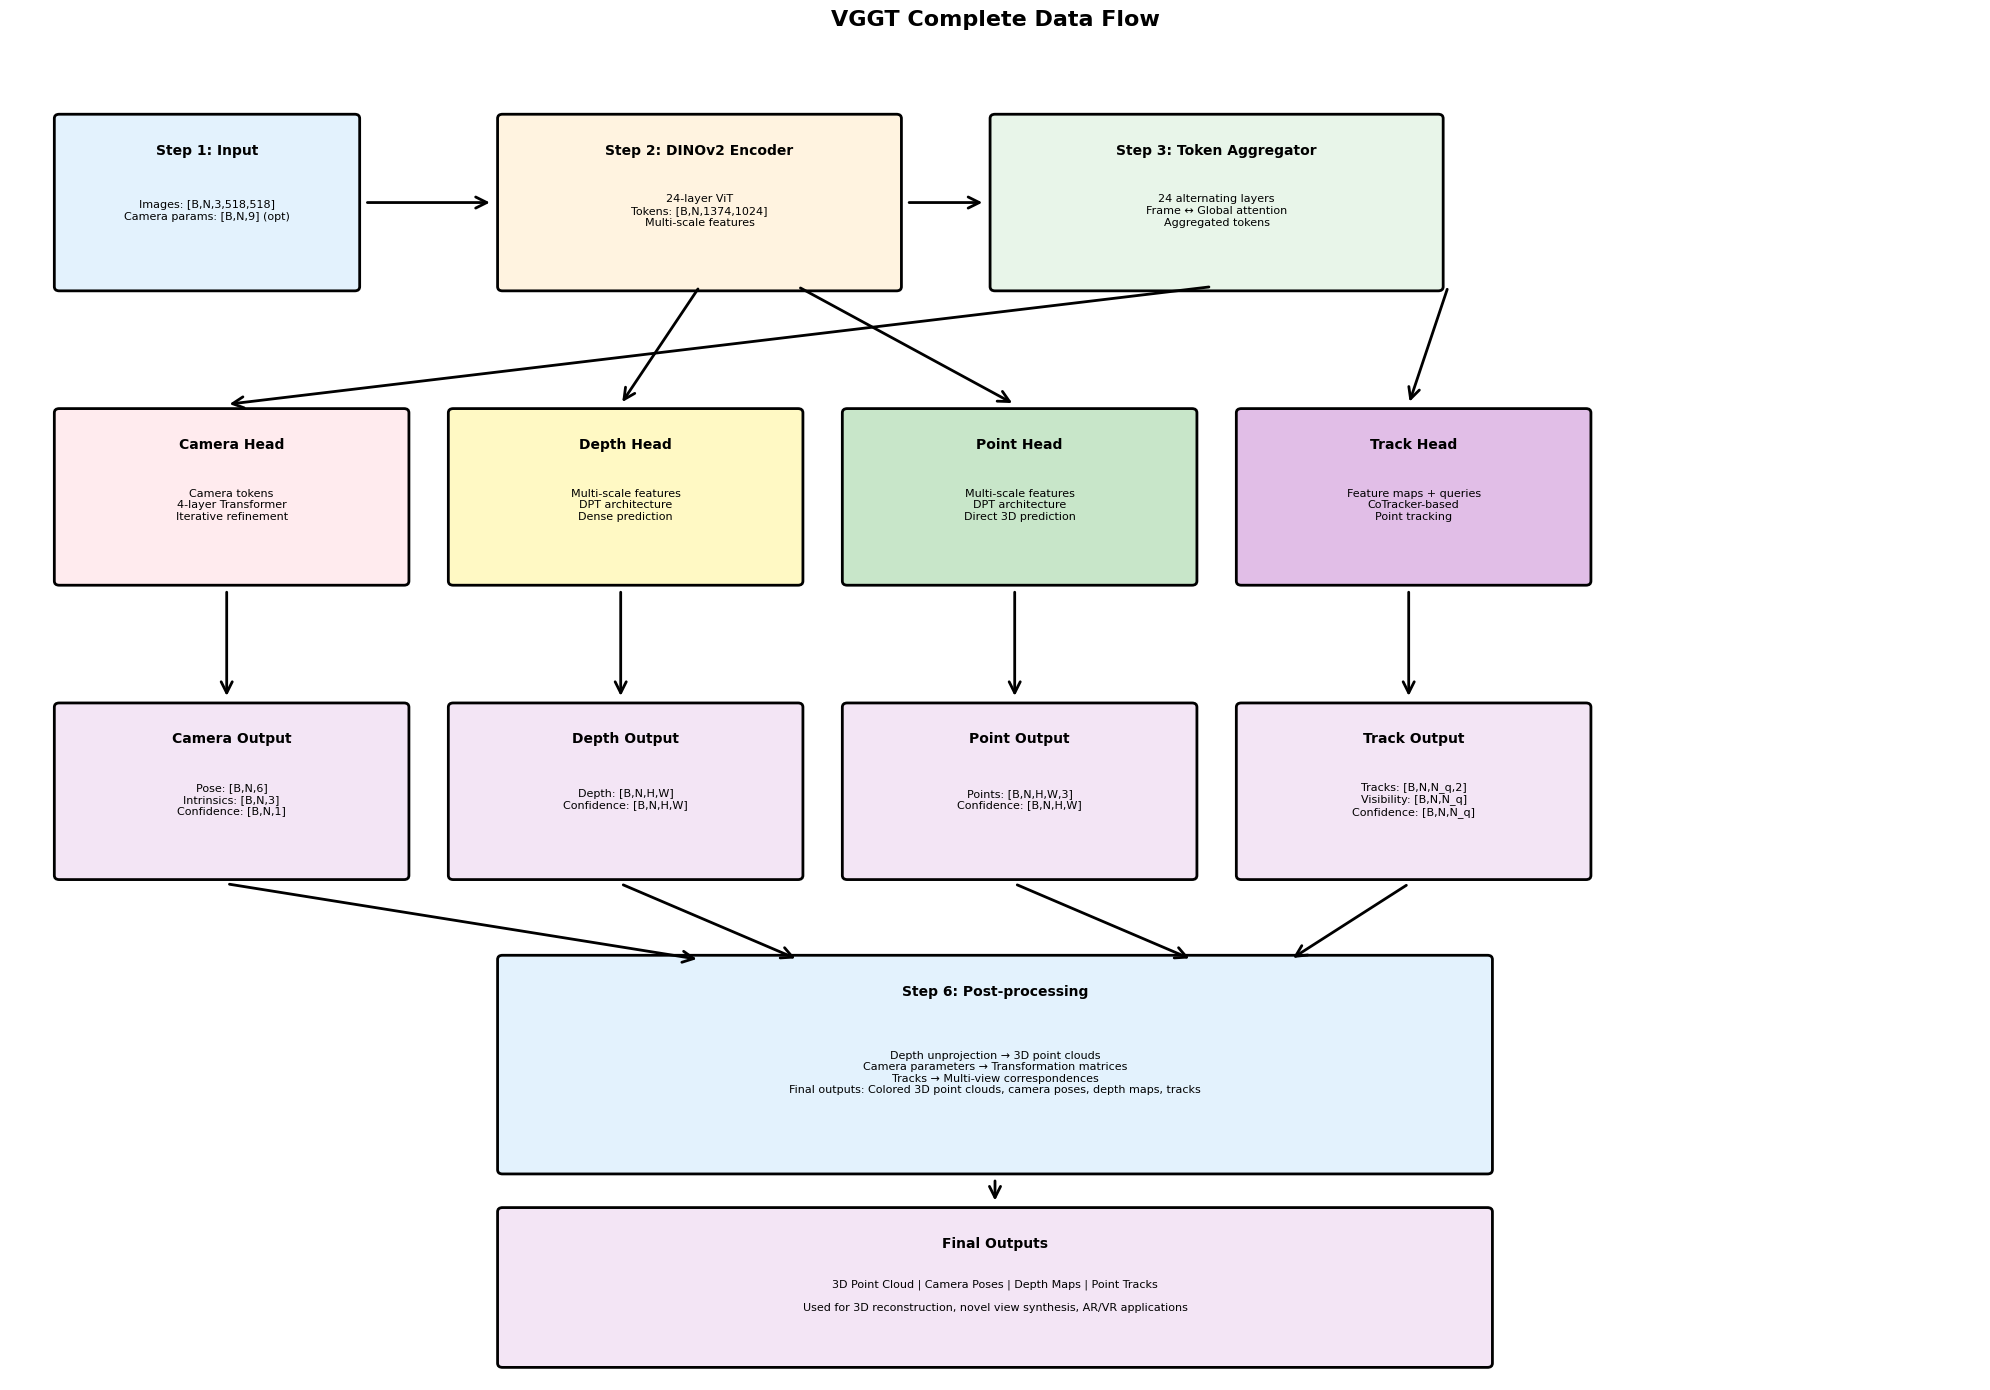


Complete Data Flow Summary:
1. Input: Multi-view images + optional camera params
2. DINOv2: Extract per-image features and tokens
3. Token Aggregator: Aggregate multi-view information
4. Multi-task Heads: Parallel prediction of all outputs
5. Post-processing: Convert to usable 3D representations
6. Output: Complete 3D scene understanding


In [9]:
# Full Data Flow Visualization
fig, ax = plt.subplots(1, 1, figsize=(20, 14))
ax.set_xlim(0, 20)
ax.set_ylim(0, 16)
ax.axis('off')
ax.set_title('VGGT Complete Data Flow', fontsize=16, fontweight='bold')

# Colors
c_input = '#E3F2FD'
c_dinov2 = '#FFF3E0'
c_aggregator = '#E8F5E9'
c_camera = '#FFEBEE'
c_depth = '#FFF9C4'
c_point = '#C8E6C9'
c_track = '#E1BEE7'
c_output = '#F3E5F5'

# Helper function to draw box
def draw_box(ax, x, y, w, h, color, title, content, fontsize=8):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                        facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(box)
    ax.text(x + w/2, y + h - 0.3, title, ha='center', va='top',
           fontsize=10, fontweight='bold')
    ax.text(x + w/2, y + h/2 - 0.1, content, ha='center', va='center',
           fontsize=fontsize)

# Helper function to draw arrow
def draw_arrow(ax, start, end, color='black'):
    arrow = FancyArrowPatch(start, end, arrowstyle='->', mutation_scale=20,
                           linewidth=2, color=color)
    ax.add_patch(arrow)

# Step 1: Input
draw_box(ax, 0.5, 13, 3, 2, c_input, 'Step 1: Input',
        'Images: [B,N,3,518,518]\nCamera params: [B,N,9] (opt)')

# Step 2: DINOv2
draw_box(ax, 5, 13, 4, 2, c_dinov2, 'Step 2: DINOv2 Encoder',
        '24-layer ViT\nTokens: [B,N,1374,1024]\nMulti-scale features')
draw_arrow(ax, (3.6, 14), (4.9, 14))

# Step 3: Token Aggregator
draw_box(ax, 10, 13, 4.5, 2, c_aggregator, 'Step 3: Token Aggregator',
        '24 alternating layers\nFrame ↔ Global attention\nAggregated tokens')
draw_arrow(ax, (9.1, 14), (9.9, 14))

# Step 4: Multi-task Heads (side by side)
# Camera Head
draw_box(ax, 0.5, 9.5, 3.5, 2, c_camera, 'Camera Head',
        'Camera tokens\n4-layer Transformer\nIterative refinement')
draw_arrow(ax, (12.2, 13), (2.2, 11.6))

# Depth Head
draw_box(ax, 4.5, 9.5, 3.5, 2, c_depth, 'Depth Head',
        'Multi-scale features\nDPT architecture\nDense prediction')
draw_arrow(ax, (7, 13), (6.2, 11.6))

# Point Head
draw_box(ax, 8.5, 9.5, 3.5, 2, c_point, 'Point Head',
        'Multi-scale features\nDPT architecture\nDirect 3D prediction')
draw_arrow(ax, (8, 13), (10.2, 11.6))

# Track Head
draw_box(ax, 12.5, 9.5, 3.5, 2, c_track, 'Track Head',
        'Feature maps + queries\nCoTracker-based\nPoint tracking')
draw_arrow(ax, (14.6, 13), (14.2, 11.6))

# Step 5: Outputs
# Camera output
draw_box(ax, 0.5, 6, 3.5, 2, c_output, 'Camera Output',
        'Pose: [B,N,6]\nIntrinsics: [B,N,3]\nConfidence: [B,N,1]')
draw_arrow(ax, (2.2, 9.4), (2.2, 8.1))

# Depth output
draw_box(ax, 4.5, 6, 3.5, 2, c_output, 'Depth Output',
        'Depth: [B,N,H,W]\nConfidence: [B,N,H,W]')
draw_arrow(ax, (6.2, 9.4), (6.2, 8.1))

# Point output
draw_box(ax, 8.5, 6, 3.5, 2, c_output, 'Point Output',
        'Points: [B,N,H,W,3]\nConfidence: [B,N,H,W]')
draw_arrow(ax, (10.2, 9.4), (10.2, 8.1))

# Track output
draw_box(ax, 12.5, 6, 3.5, 2, c_output, 'Track Output',
        'Tracks: [B,N,N_q,2]\nVisibility: [B,N,N_q]\nConfidence: [B,N,N_q]')
draw_arrow(ax, (14.2, 9.4), (14.2, 8.1))

# Step 6: Post-processing
draw_box(ax, 5, 2.5, 10, 2.5, c_input, 'Step 6: Post-processing',
        'Depth unprojection → 3D point clouds\nCamera parameters → Transformation matrices\nTracks → Multi-view correspondences\nFinal outputs: Colored 3D point clouds, camera poses, depth maps, tracks')

# Arrows to post-processing
draw_arrow(ax, (2.2, 5.9), (7, 5))
draw_arrow(ax, (6.2, 5.9), (8, 5))
draw_arrow(ax, (10.2, 5.9), (12, 5))
draw_arrow(ax, (14.2, 5.9), (13, 5))

# Final outputs
draw_box(ax, 5, 0.2, 10, 1.8, c_output, 'Final Outputs',
        '3D Point Cloud | Camera Poses | Depth Maps | Point Tracks\n\nUsed for 3D reconstruction, novel view synthesis, AR/VR applications')
draw_arrow(ax, (10, 2.4), (10, 2.1))

plt.tight_layout()
plt.savefig('data_flow.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nComplete Data Flow Summary:")
print("1. Input: Multi-view images + optional camera params")
print("2. DINOv2: Extract per-image features and tokens")
print("3. Token Aggregator: Aggregate multi-view information")
print("4. Multi-task Heads: Parallel prediction of all outputs")
print("5. Post-processing: Convert to usable 3D representations")
print("6. Output: Complete 3D scene understanding")

## 8. Interactive Example: Forward Pass

Let's create a simplified forward pass simulation to understand the tensor shapes at each stage.

In [10]:
# Simplified VGGT Forward Pass Simulation
print("=" * 80)
print("                    Simplified VGGT Forward Pass")
print("=" * 80)

# Configuration
B = 2      # Batch size
N = 4      # Number of images
H = 518    # Image height
W = 518    # Image width
T = 1369   # Tokens per image (37×37)
D = 1024   # Hidden dimension
P = 14     # Patch size

print(f"\nConfiguration:")
print(f"  Batch size (B): {B}")
print(f"  Number of images (N): {N}")
print(f"  Image size: {H}×{W}")
print(f"  Patch size: {P}×{P}")
print(f"  Tokens per image (T): {T} ({int(T**0.5)}×{int(T**0.5)})")
print(f"  Hidden dimension (D): {D}")

# Step 1: Input
print(f"\n{'='*80}")
print("STEP 1: Input")
print(f"{'='*80}")
images = torch.randn(B, N, 3, H, W)
camera_params = torch.randn(B, N, 9)  # Optional
print(f"  images: {list(images.shape)}")
print(f"  camera_params: {list(camera_params.shape)} (optional)")

# Step 2: DINOv2 Encoding
print(f"\n{'='*80}")
print("STEP 2: DINOv2 Encoding")
print(f"{'='*80}")
# Each image independently processed
image_tokens = torch.randn(B, N, T + 5, D)  # 1374 tokens = 1369 patches + 4 reg + 1 cam
print(f"  Processing {N} images independently...")
print(f"  image_tokens: {list(image_tokens.shape)}")
print(f"    - 1 Camera token")
print(f"    - 4 Register tokens")
print(f"    - {T} Patch tokens")

# Multi-scale features
multi_scale_features = [
    torch.randn(B, N, D, H//P, W//P),      # Layer 4
    torch.randn(B, N, D, H//P//2, W//P//2),   # Layer 11
    torch.randn(B, N, D, H//P//4, W//P//4),   # Layer 17
    torch.randn(B, N, D, H//P//8, W//P//8),   # Layer 23
]
print(f"\n  Multi-scale features extracted:")
for i, (layer_id, feat) in enumerate(zip([4, 11, 17, 23], multi_scale_features)):
    print(f"    Layer {layer_id}: {list(feat.shape)}")

# Step 3: Token Aggregation
print(f"\n{'='*80}")
print("STEP 3: Token Aggregation (24 Layers)")
print(f"{'='*80}")
aggregated_tokens = image_tokens.clone()

print(f"  Input: {list(aggregated_tokens.shape)}")
print(f"\n  Processing 24 alternating attention layers:")

for layer_id in range(1, 25):
    is_global = layer_id % 2 == 0
    mode = "Global" if is_global else "Frame"
    
    if is_global:
        # Global attention: all tokens attend to all tokens
        # [B, N, T+5, D] -> [B, N*(T+5), D] -> attention -> [B, N, T+5, D]
        tokens_flat = aggregated_tokens.view(B, N * (T + 5), D)
        # Simulate attention (simplified)
        tokens_flat = tokens_flat + 0.1 * torch.randn_like(tokens_flat)
        aggregated_tokens = tokens_flat.view(B, N, T + 5, D)
    else:
        # Frame attention: tokens within each image attend to each other
        # [B, N, T+5, D] -> [B*N, T+5, D] -> attention -> [B, N, T+5, D]
        tokens_flat = aggregated_tokens.view(B * N, T + 5, D)
        # Simulate attention (simplified)
        tokens_flat = tokens_flat + 0.1 * torch.randn_like(tokens_flat)
        aggregated_tokens = tokens_flat.view(B, N, T + 5, D)
    
    if layer_id <= 4 or layer_id >= 22:
        print(f"    Layer {layer_id:2d} ({mode:6s}): {list(aggregated_tokens.shape)}")
    elif layer_id == 5:
        print(f"    ...")

print(f"\n  Output: {list(aggregated_tokens.shape)}")

# Step 4: Multi-task Prediction
print(f"\n{'='*80}")
print("STEP 4: Multi-task Prediction")
print(f"{'='*80}")

# Extract camera tokens
camera_tokens = aggregated_tokens[:, :, 0, :]  # [B, N, D]
print(f"\n  Camera tokens: {list(camera_tokens.shape)}")

# Camera Head
camera_output = torch.randn(B, N, 9)  # [translation (3) + quaternion (4) + FoV (2)]
print(f"  Camera Head output: {list(camera_output.shape)}")
print(f"    - Translation: {list(camera_output[..., :3].shape)}")
print(f"    - Quaternion: {list(camera_output[..., 3:7].shape)}")
print(f"    - FoV: {list(camera_output[..., 7:9].shape)}")

# Depth Head
depth = torch.randn(B, N, H, W)
depth_conf = torch.randn(B, N, H, W)
print(f"\n  Depth Head output:")
print(f"    - Depth: {list(depth.shape)}")
print(f"    - Confidence: {list(depth_conf.shape)}")

# Point Head
points = torch.randn(B, N, H, W, 3)
point_conf = torch.randn(B, N, H, W)
print(f"\n  Point Head output:")
print(f"    - Points: {list(points.shape)}")
print(f"    - Confidence: {list(point_conf.shape)}")

# Track Head
N_q = 100  # Number of query points
tracks = torch.randn(B, N, N_q, 2)
visibility = torch.randn(B, N, N_q)
track_conf = torch.randn(B, N, N_q)
print(f"\n  Track Head output:")
print(f"    - Tracks: {list(tracks.shape)}")
print(f"    - Visibility: {list(visibility.shape)}")
print(f"    - Confidence: {list(track_conf.shape)}")

# Step 5: Post-processing
print(f"\n{'='*80}")
print("STEP 5: Post-processing")
print(f"{'='*80}")
print(f"  Converting outputs to 3D representations...")
print(f"  • Depth unprojection → 3D points")
print(f"  • Camera params → Extrinsic matrices")
print(f"  • Tracks → Multi-view correspondences")

print(f"\n{'='*80}")
print("                    Forward Pass Complete!")
print(f"{'='*80}")
print(f"\nFinal outputs:")
print(f"  • Camera poses: {list(camera_output.shape)}")
print(f"  • Depth maps: {list(depth.shape)}")
print(f"  • Point clouds: {list(points.shape)} or unprojected")
print(f"  • Point tracks: {list(tracks.shape)}")

                    Simplified VGGT Forward Pass

Configuration:
  Batch size (B): 2
  Number of images (N): 4
  Image size: 518×518
  Patch size: 14×14
  Tokens per image (T): 1369 (37×37)
  Hidden dimension (D): 1024

STEP 1: Input
  images: [2, 4, 3, 518, 518]
  camera_params: [2, 4, 9] (optional)

STEP 2: DINOv2 Encoding
  Processing 4 images independently...
  image_tokens: [2, 4, 1374, 1024]
    - 1 Camera token
    - 4 Register tokens
    - 1369 Patch tokens

  Multi-scale features extracted:
    Layer 4: [2, 4, 1024, 37, 37]
    Layer 11: [2, 4, 1024, 18, 18]
    Layer 17: [2, 4, 1024, 9, 9]
    Layer 23: [2, 4, 1024, 4, 4]

STEP 3: Token Aggregation (24 Layers)
  Input: [2, 4, 1374, 1024]

  Processing 24 alternating attention layers:


    Layer  1 (Frame ): [2, 4, 1374, 1024]
    Layer  2 (Global): [2, 4, 1374, 1024]
    Layer  3 (Frame ): [2, 4, 1374, 1024]


    Layer  4 (Global): [2, 4, 1374, 1024]
    ...


    Layer 22 (Global): [2, 4, 1374, 1024]
    Layer 23 (Frame ): [2, 4, 1374, 1024]
    Layer 24 (Global): [2, 4, 1374, 1024]

  Output: [2, 4, 1374, 1024]

STEP 4: Multi-task Prediction

  Camera tokens: [2, 4, 1024]
  Camera Head output: [2, 4, 9]
    - Translation: [2, 4, 3]
    - Quaternion: [2, 4, 4]
    - FoV: [2, 4, 2]



  Depth Head output:
    - Depth: [2, 4, 518, 518]
    - Confidence: [2, 4, 518, 518]

  Point Head output:
    - Points: [2, 4, 518, 518, 3]
    - Confidence: [2, 4, 518, 518]

  Track Head output:
    - Tracks: [2, 4, 100, 2]
    - Visibility: [2, 4, 100]
    - Confidence: [2, 4, 100]

STEP 5: Post-processing
  Converting outputs to 3D representations...
  • Depth unprojection → 3D points
  • Camera params → Extrinsic matrices
  • Tracks → Multi-view correspondences

                    Forward Pass Complete!

Final outputs:
  • Camera poses: [2, 4, 9]
  • Depth maps: [2, 4, 518, 518]
  • Point clouds: [2, 4, 518, 518, 3] or unprojected
  • Point tracks: [2, 4, 100, 2]


## Summary

### What We've Learned

1. **Complete Architecture**: VGGT consists of DINOv2 backbone, Token Aggregator, and Multi-task Heads

2. **DINOv2 Backbone**: 
   - 24-layer ViT encoder with 1024 hidden dimensions
   - Processes each image independently to produce 1374 tokens per image
   - Extracts multi-scale features from layers [4, 11, 17, 23]

3. **Patch Embedding**: 
   - 518×518 images divided into 14×14 patches (37×37 grid)
   - Linear projection to 1024 dimensions
   - Learned positional encodings added

4. **Special Tokens**:
   - Camera Token: Image-level representation and pose prediction
   - Register Tokens (4): Distributed memory for global context
   - Patch Tokens (1369): Local region representations
   - patch_start_index = 5 (critical for indexing)

5. **Token Aggregator**:
   - 24 alternating attention layers (12 frame + 12 global)
   - Frame attention: Within-image processing (O(N·T²))
   - Global attention: Cross-image processing (O((N·T)²))
   - Achieves 1.8-2× speedup over all-global attention

6. **Data Flow**:
   - Input → DINOv2 → Token Aggregator → Multi-task Heads → Post-processing
   - Parallel prediction of camera, depth, point, and track outputs
   - Final 3D representations for downstream applications

### Key Takeaways

- **Alternating attention** is the key innovation enabling scalable multi-view processing
- **Special tokens** (camera + registers) provide crucial inductive biases
- **Multi-scale features** from DINOv2 enable high-quality dense predictions
- **Unified architecture** jointly learns multiple 3D vision tasks

### Next Steps

In the next notebooks, we'll explore:
- **Notebook 04**: DPT Multi-scale Architecture
- **Notebook 05**: Training Objectives and Loss Functions
- **Notebook 06**: Code Walkthrough
- **Notebook 07**: Inference and Visualization